## Imports

<a href="https://colab.research.google.com/github/sylvainestebe/european-city-inference/blob/main/notebooks/tutorial_1_decision_making.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import jax
import matplotlib.pyplot as plt
import pandas as pd

from eci.environment import EnvConfig, Environment
from eci.metrics import batch_compute_metrics
from eci.plots import plot_preference, plot_voting_metrics
from eci.utils import _extract_env_data_vectorized
from eci.voting_system.plurality import _vote_plurality
from eci.voting_system.quadratic import _vote_quadratic

# TODO: restore `strategic_vote` and `strategic_quadratic_vote` (currently
# commented out in plurality.py / quadratic.py).

## Parameter Configuration 
The simulation constants are defined here.

In [2]:
config = EnvConfig(
    num_voters=100,
    num_candidates=5,
    num_preferences=4,
)
NUM_SIMULATIONS = 100_000  # Number of simulation steps

## Environment Initialization 
The environment is created using the parameters defined above.

In [3]:
# Initialize environment
env = Environment(config)
env.num_simulations = NUM_SIMULATIONS
env._run_multi_agent_inference()

In [4]:
data = _extract_env_data_vectorized(env)

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_97041/3319045621.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


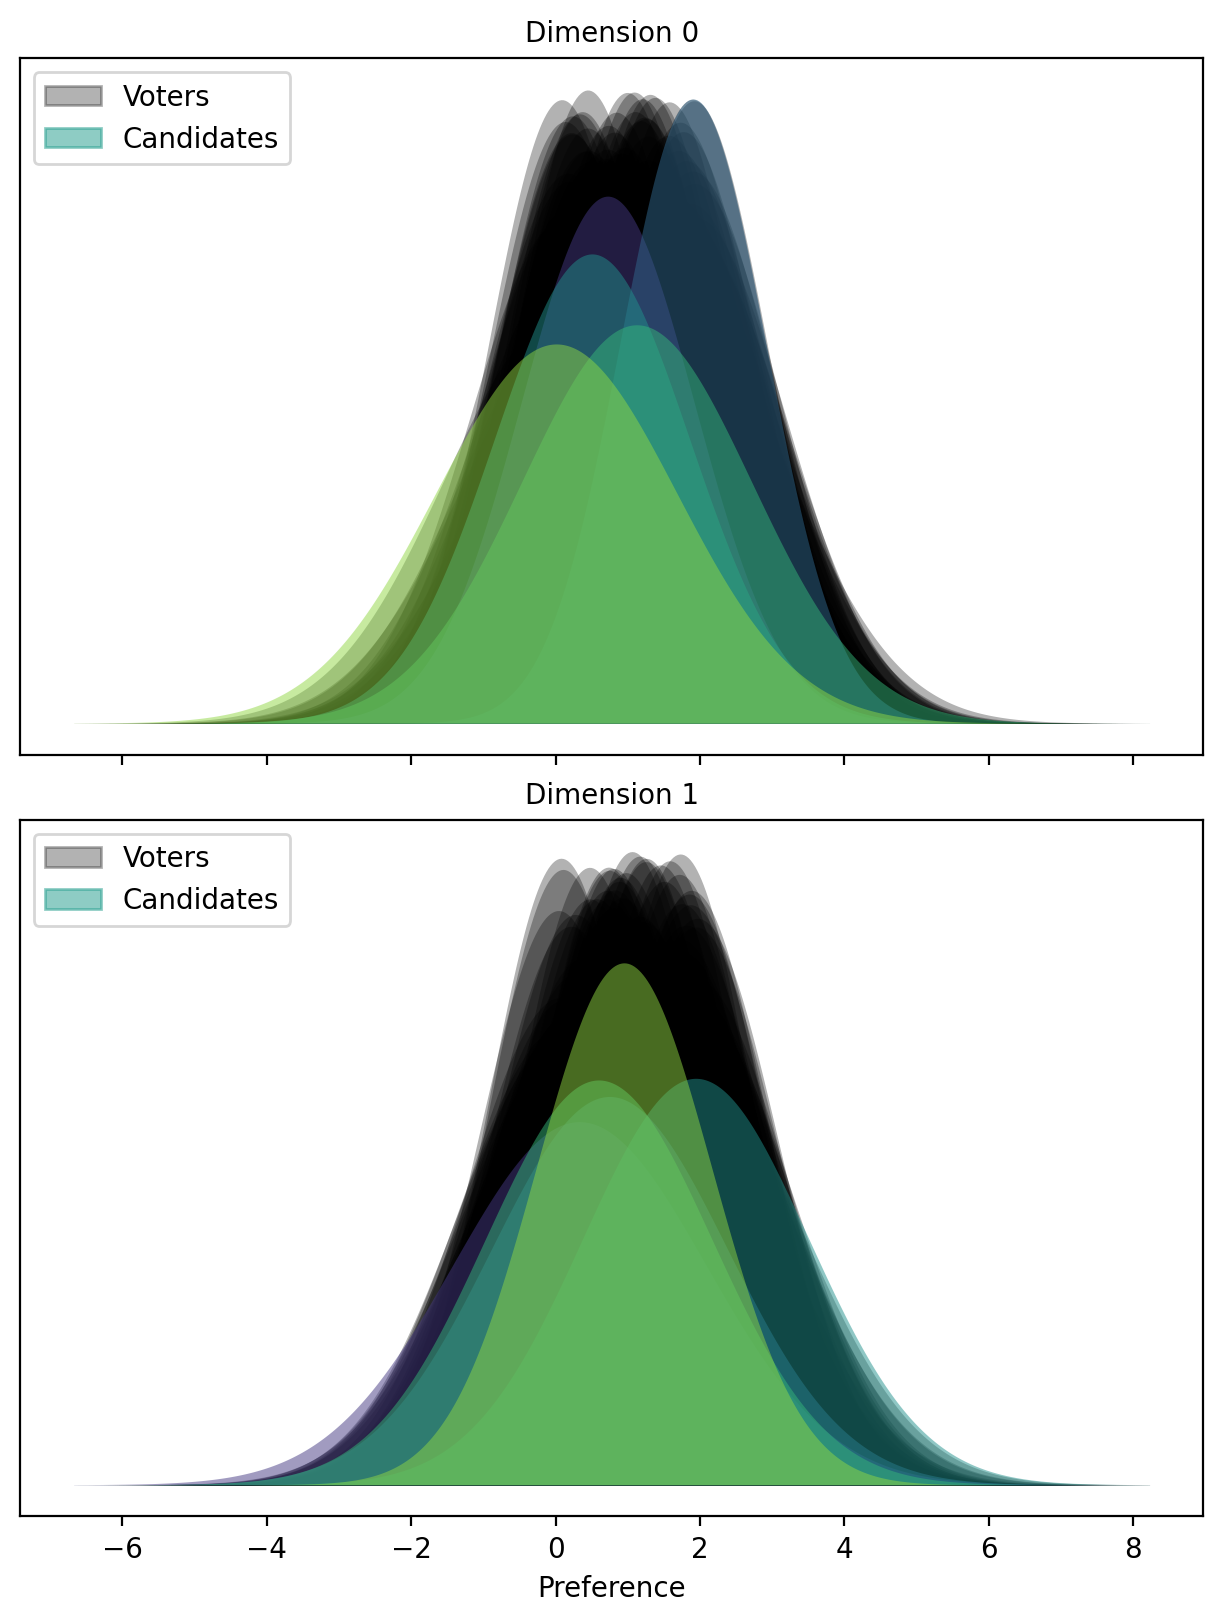

In [5]:
fig, ax = plot_preference(data)
fig.show()

## Voting systems
Now we will explore the different voting system implemented.

### Plurality Voting
Then we have the plurality voting where agent vote for the candidate they prefer the most and the candidate with the maximum vote win. This is done in two round if there is no majority.

In [ ]:
from eci.voting_system.decisions import response_function

data = _extract_env_data_vectorized(env)
key = jax.random.PRNGKey(42)
# Run simulations
sim_plurality = env.run_n_simulation(
    func=_vote_plurality,
    data=data,
    response_function=response_function,
    key=key,
    n_simulations=NUM_SIMULATIONS,
)
# sim_plurality_strat = env.run_n_simulation(func=strategic_vote, data=data,
# response_function=response_function, key=key, n_simulations=NUM_SIMULATIONS)
# Compute metrics
metrics_plurality = batch_compute_metrics(sim_plurality)
# metrics_plurality_strat = batch_compute_metrics(sim_plurality_strat)

Running Simulations: 100%|██████████| 100000/100000 [01:22<00:00, 1218.23it/s]


### Quadratic Voting
Then the quadratic voting where agent have credits and should spend them on the candidates they prefer, they candidat with most of the vote win.

In [ ]:
# Run simulations
sim_qv = env.run_n_simulation(
    _vote_quadratic,
    data=data,
    response_function=response_function,
    key=key,
    n_simulations=NUM_SIMULATIONS,
)
# sim_qv_strat = env.run_n_simulation(strategic_quadratic_vote, data=data,
# response_function=response_function, key=key, n_simulations=NUM_SIMULATIONS)

# Compute metrics
metrics_qv = batch_compute_metrics(sim_qv)
# metrics_qv_strat = batch_compute_metrics(sim_qv_strat)

Running Simulations: 100%|██████████| 100000/100000 [01:16<00:00, 1315.52it/s]


# Metrics
This section compares how different voting systems represent voter preferences and satisfaction. The **Winner Satisfaction** measures how well the winning candidate aligns with voters’ preferences:
and the **Vote Efficiency** evaluates how well votes reflect voters’ true preferences.

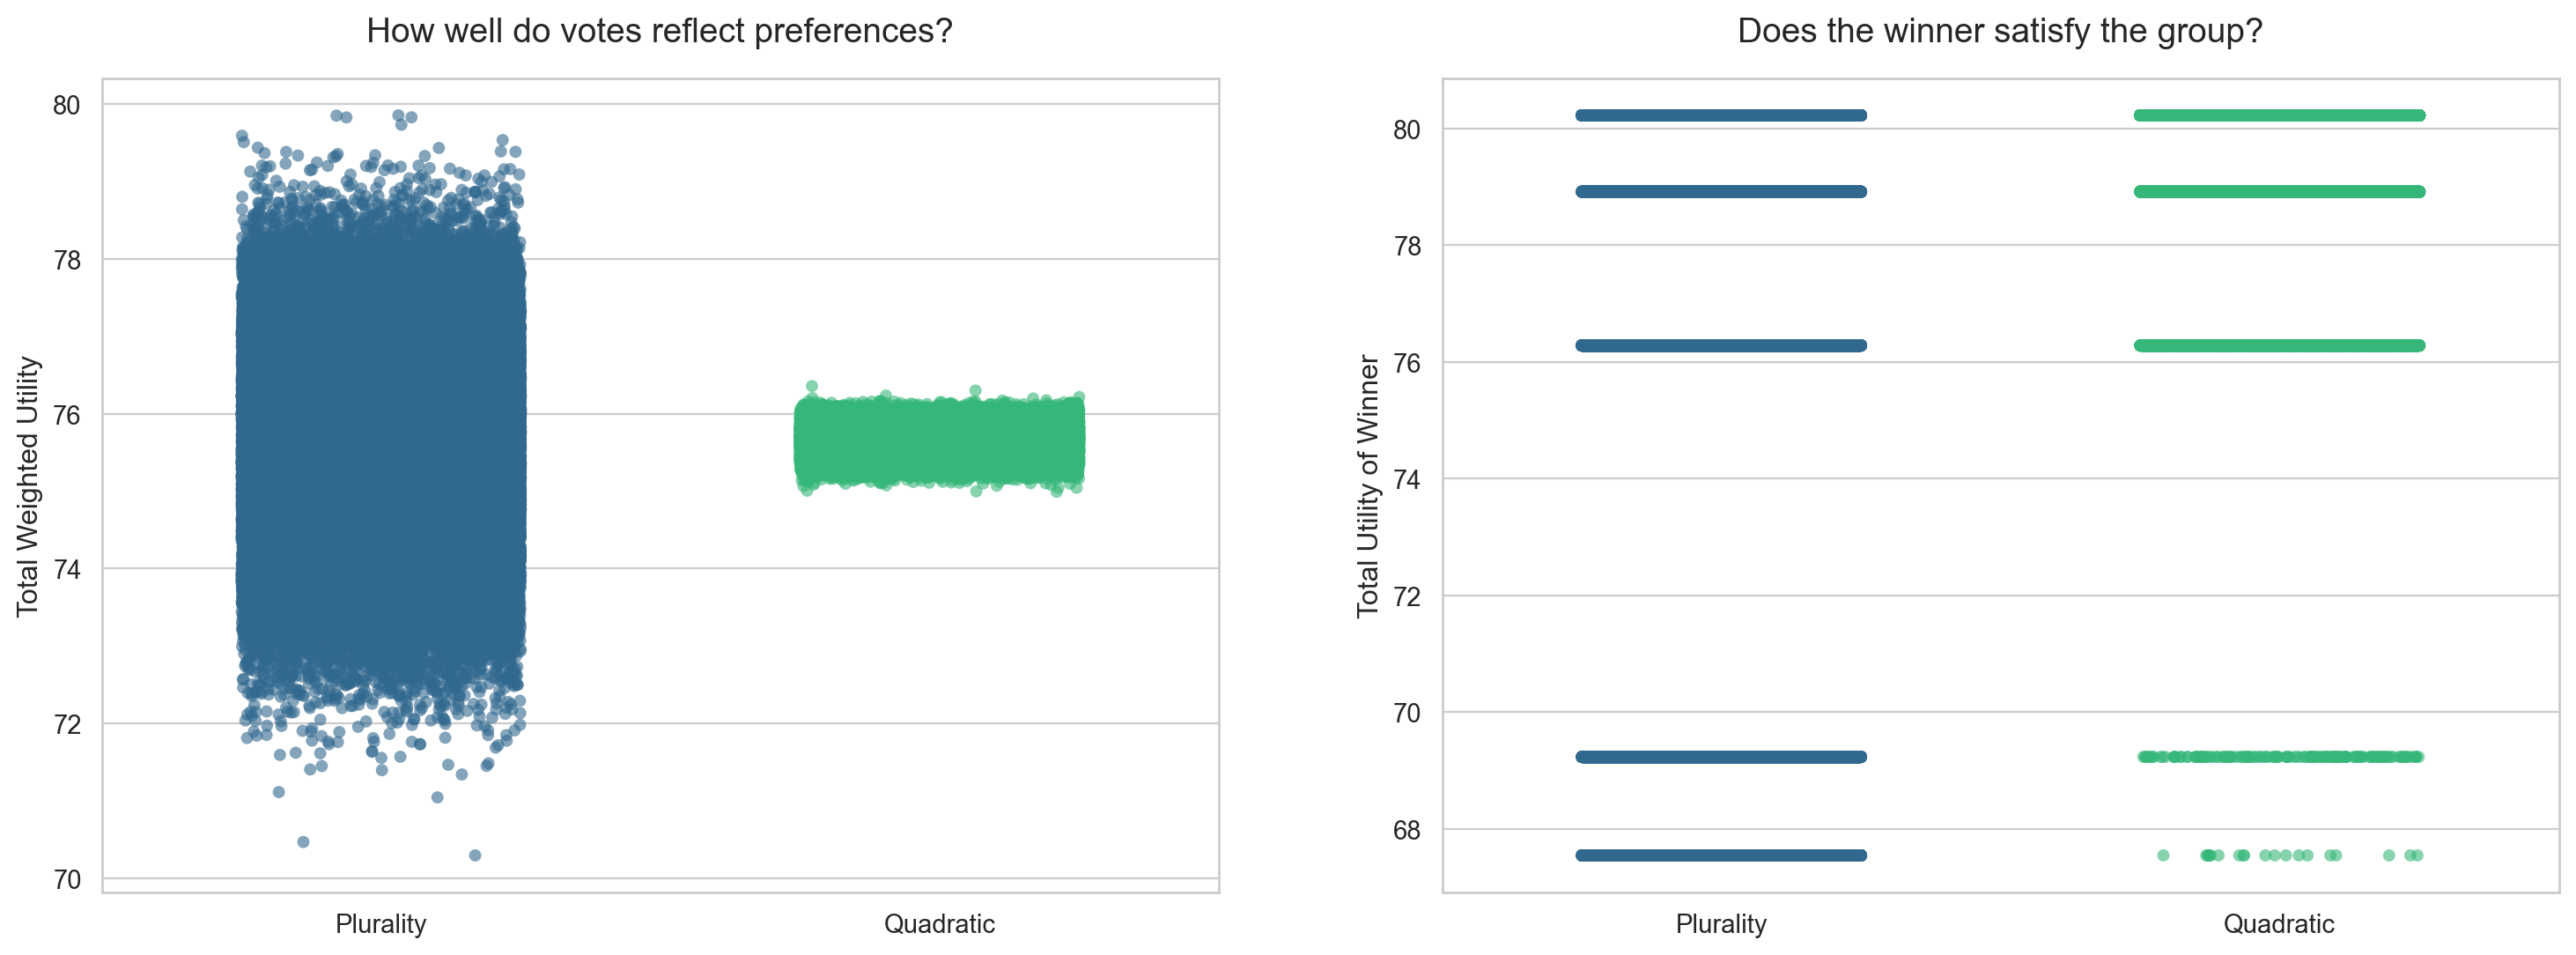

In [8]:
# change voting system labels
metrics_plurality["voting_system"] = "Plurality"
# metrics_plurality_strat["voting_system"] = "Plurality_Strat"
metrics_qv["voting_system"] = "Quadratic"
# metrics_qv_strat["voting_system"] = "Quadrati_Strat"

# combine dataframes
combined_df = pd.concat(
    [
        metrics_plurality,
        metrics_qv,
    ],
    ignore_index=True,
)

# plot voting metrics
fig = plot_voting_metrics(combined_df)
plt.show()